<a href="https://colab.research.google.com/github/debanganmana/data-science-project/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data= pd.read_csv(r"C:\Users\singh\Downloads\archive (4)\healthcare-dataset-stroke-data.csv")
data.shape

(5110, 12)

In [ ]:
data.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
727,50811,Male,24.0,0,0,No,Private,Urban,119.34,38.5,never smoked,0
3734,51852,Female,13.0,0,0,No,children,Rural,219.81,NaN,Unknown,0
3667,3777,Female,28.0,1,0,Yes,Govt_job,Rural,83.66,36.4,never smoked,0
3990,70661,Female,28.0,0,0,No,Private,Rural,134.12,28.8,formerly smoked,0
506,63958,Female,42.0,0,0,Yes,Private,Urban,96.99,34.8,formerly smoked,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [ ]:
(201/5110)*100

3.9334637964774952

In [ ]:
data.dropna(subset = "bmi",inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   object 
 2   age                4909 non-null   float64
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   object 
 6   work_type          4909 non-null   object 
 7   Residence_type     4909 non-null   object 
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   object 
 11  stroke             4909 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 498.6+ KB


In [ ]:
data["age"]=data["age"].astype("int64")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   object 
 2   age                4909 non-null   int64  
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   object 
 6   work_type          4909 non-null   object 
 7   Residence_type     4909 non-null   object 
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   object 
 11  stroke             4909 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 498.6+ KB


In [ ]:
cat_col=["hypertension","heart_disease","stroke"]

for col in cat_col:
    data[col]=data[col].astype("category")


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 4909 non-null   int64   
 1   gender             4909 non-null   object  
 2   age                4909 non-null   int64   
 3   hypertension       4909 non-null   category
 4   heart_disease      4909 non-null   category
 5   ever_married       4909 non-null   object  
 6   work_type          4909 non-null   object  
 7   Residence_type     4909 non-null   object  
 8   avg_glucose_level  4909 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     4909 non-null   object  
 11  stroke             4909 non-null   category
dtypes: category(3), float64(2), int64(2), object(5)
memory usage: 398.3+ KB


In [ ]:
categorical_column=data.select_dtypes(include=["object","category"]).columns
categorical_column

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
for cat in categorical_column:
    print(data[cat].value_counts())
    print("="*30+"\n")

gender
Female    2897
Male      2011
Other        1
Name: count, dtype: int64

hypertension
0    4458
1     451
Name: count, dtype: int64

heart_disease
0    4666
1     243
Name: count, dtype: int64

ever_married
Yes    3204
No     1705
Name: count, dtype: int64

work_type
Private          2811
Self-employed     775
children          671
Govt_job          630
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2490
Rural    2419
Name: count, dtype: int64

smoking_status
never smoked       1852
Unknown            1483
formerly smoked     837
smokes              737
Name: count, dtype: int64

stroke
0    4700
1     209
Name: count, dtype: int64



In [ ]:
for cat in categorical_column:
    data[cat]=data[cat].astype("category")


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 4909 non-null   int64   
 1   gender             4909 non-null   category
 2   age                4909 non-null   int64   
 3   hypertension       4909 non-null   category
 4   heart_disease      4909 non-null   category
 5   ever_married       4909 non-null   category
 6   work_type          4909 non-null   category
 7   Residence_type     4909 non-null   category
 8   avg_glucose_level  4909 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     4909 non-null   category
 11  stroke             4909 non-null   category
dtypes: category(8), float64(2), int64(2)
memory usage: 231.2 KB


In [ ]:
data["stroke"].value_counts(normalize = True)

stroke
0    0.957425
1    0.042575
Name: proportion, dtype: float64

In [ ]:
data.sample(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
653,72823,Female,79,0,0,Yes,Private,Urban,70.35,23.0,formerly smoked,0
3364,66973,Male,43,0,0,Yes,Private,Urban,92.71,30.5,formerly smoked,0
3693,36593,Male,38,0,0,No,Private,Rural,162.72,31.9,smokes,0
2567,65564,Female,48,0,0,Yes,Private,Urban,57.43,53.5,formerly smoked,0
1885,52428,Male,25,0,0,No,Private,Urban,116.12,20.4,smokes,0
306,16371,Female,13,0,0,No,children,Urban,75.42,40.1,Unknown,0
3323,8410,Female,8,0,0,No,children,Rural,98.90,18.8,Unknown,0
4534,49053,Female,45,0,0,No,Private,Rural,120.56,31.6,never smoked,0
2289,33284,Male,18,0,0,No,Private,Rural,75.03,23.4,never smoked,0
392,44862,Female,39,0,0,Yes,Private,Rural,83.51,26.4,never smoked,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
for col in categorical_column:
    le = LabelEncoder()
    data[col]=le.fit_transform(data[col])


In [ ]:
data.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4233,18352,0,3,0,0,0,4,0,108.32,14.2,0,0
2872,42284,1,71,1,0,1,3,0,97.57,26.9,0,0
3603,28247,1,82,0,0,0,3,1,101.57,24.3,3,0
3482,30571,0,38,0,0,1,0,0,78.94,23.5,0,0
4909,70540,0,39,0,0,1,2,1,243.52,37.2,3,0


In [ ]:
data[data['age'] >=82]['stroke'].value_counts()

stroke
0    46
1     9
Name: count, dtype: int64

In [ ]:
x=data.drop(columns = ["id","stroke"])
y=data["stroke"]
x.sample(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
3998,0,27,0,0,1,2,1,139.20,36.2,2
147,0,78,0,0,1,2,1,67.29,24.6,2
1498,1,38,0,0,0,2,0,86.86,36.5,0
4108,1,29,0,0,1,2,1,70.51,24.5,0
2171,1,18,0,0,0,2,0,120.58,21.5,2


In [ ]:
corr_matrix = x.corr()
corr_matrix

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
gender,1.000000,-0.030823,0.021578,0.082712,-0.037237,0.058560,-0.005014,0.053664,-0.026678,-0.060004
age,-0.030823,1.000000,0.274329,0.256999,0.680834,-0.367481,0.010942,0.235725,0.333738,0.275902
hypertension,0.021578,0.274329,1.000000,0.115991,0.162406,-0.052750,-0.001074,0.180543,0.167811,0.110808
heart_disease,0.082712,0.256999,0.115991,1.000000,0.111245,-0.030373,-0.002362,0.154525,0.041357,0.055236
ever_married,-0.037237,0.680834,0.162406,0.111245,1.000000,-0.357946,0.004989,0.151377,0.341695,0.264642
work_type,0.058560,-0.367481,-0.052750,-0.030373,-0.357946,1.000000,-0.005422,-0.050581,-0.304876,-0.310911
Residence_type,-0.005014,0.010942,-0.001074,-0.002362,0.004989,-0.005422,1.000000,-0.007617,-0.000122,0.013810
avg_glucose_level,0.053664,0.235725,0.180543,0.154525,0.151377,-0.050581,-0.007617,1.000000,0.175502,0.066335
bmi,-0.026678,0.333738,0.167811,0.041357,0.341695,-0.304876,-0.000122,0.175502,1.000000,0.224473
smoking_status,-0.060004,0.275902,0.110808,0.055236,0.264642,-0.310911,0.013810,0.066335,0.224473,1.000000


<Axes: >

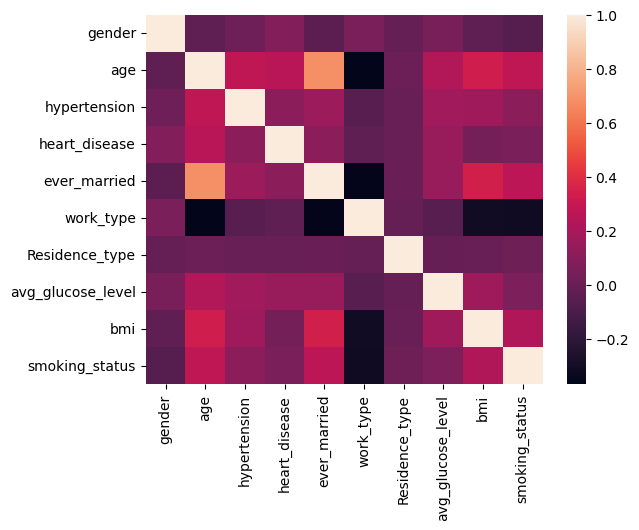

In [ ]:
import seaborn as sns
sns.heatmap(corr_matrix)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4909 non-null   int64  
 1   gender             4909 non-null   int64  
 2   age                4909 non-null   int64  
 3   hypertension       4909 non-null   int64  
 4   heart_disease      4909 non-null   int64  
 5   ever_married       4909 non-null   int64  
 6   work_type          4909 non-null   int64  
 7   Residence_type     4909 non-null   int64  
 8   avg_glucose_level  4909 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     4909 non-null   int64  
 11  stroke             4909 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 498.6 KB


In [ ]:
# upsampling

from sklearn.utils import resample

majority_class = data[data["stroke"]== 0]
minority_class = data[data["stroke"]== 1]

In [ ]:
#upsampling minority class
minority_upsampling = resample(minority_class, replace = True, n_samples=2500,random_state = 42)

In [ ]:
2500+4700

7200

In [ ]:
2500/7200

0.3472222222222222

In [ ]:
balanced_data_upscaling=pd.concat([majority_class,minority_upsampling])

In [ ]:
balanced_data_upscaling.shape

(7200, 12)

In [ ]:
balanced_data_upscaling['stroke'].value_counts(normalize = True)

stroke
0    0.652778
1    0.347222
Name: proportion, dtype: float64

In [ ]:
#downscaling

majority_downsampling = resample(majority_class, replace =False, n_samples = 409,random_state = 42)

In [ ]:
209/609

0.34318555008210183

In [ ]:
609-209

400

In [ ]:
balanced_data_downscaling=pd.concat([majority_downsampling,minority_class])

In [ ]:
balanced_data_downscaling['stroke'].value_counts(normalize = True)

stroke
0    0.661812
1    0.338188
Name: proportion, dtype: float64

In [ ]:
# mixed approach for downsampling if sampoles becomes very less
majority_downsampling = resample(majority_class, replace =False, n_samples = 2500,random_state = 42)
balanced_data_mixedscaling=pd.concat([majority_downsampling,minority_upsampling])
balanced_data_mixedscaling['stroke'].value_counts(normalize = True)

stroke
0    0.5
1    0.5
Name: proportion, dtype: float64

In [ ]:
balanced_data_mixedscaling.shape

(5000, 12)

In [ ]:
#Smote Technique is applied only on training dataset not on test dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42, stratify = y)

In [ ]:
from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state = 42)
x_resample,y_resample = smote.fit_resample(x_train,y_train)

In [ ]:
df_balanced = pd.DataFrame(x_resample,columns = x.columns)
df_balanced["stroke"] = y_resample

In [ ]:
df_balanced.sample(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1458,0,43,0,0,1,0,0,72.130000,42.600000,2,0
3203,1,28,0,0,1,2,1,87.430000,55.700000,0,0
2236,1,81,0,0,1,3,1,99.330000,33.700000,2,1
6666,0,61,0,1,1,1,0,113.837950,37.283361,3,1
3399,1,11,0,0,0,4,1,141.840000,23.300000,0,0
1452,0,40,0,0,1,2,0,139.900000,31.700000,3,0
4130,0,74,0,0,1,0,0,191.743104,27.861896,2,1
3567,1,65,0,0,1,3,0,94.640000,28.600000,2,0
2316,1,62,0,0,1,2,1,81.640000,38.200000,2,0
1998,1,41,0,0,1,0,1,84.100000,29.300000,2,0


In [ ]:
df_balanced["stroke"].value_counts(normalize = True)

stroke
0    0.5
1    0.5
Name: proportion, dtype: float64

In [ ]:
df_balanced.duplicated().sum()

np.int64(0)

In [ ]:
balanced_data_mixedscaling.duplicated().sum()

np.int64(2291)

In [ ]:
balanced_data_downscaling.duplicated().sum()

np.int64(0)

In [ ]:
balanced_data_upscaling.duplicated().sum()

np.int64(2291)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_resample)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_resample)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
pred = LR.predict(x_test)
from sklearn.metrics import accuracy_score,precision_score,f1_score
acc = accuracy_score(y_test,pred)
f1 = f1_score(y_test,pred)
precision = precision_score(y_test,pred)
print("acc","-->",acc)
print("f1","-->",f1)
print("precision","-->",precision)

acc --> 0.774949083503055
f1 --> 0.18450184501845018
precision --> 0.1091703056768559
